<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_A_classificacao_breast_cancer_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade A — Classificação do Breast Cancer Wisconsin
## Versão metodologicamente corrigida

Este notebook compara:

- Árvore de Decisão
- KNN
- Naive Bayes
- SVM
- MLP
- Random Forest
- Bagging
- AdaBoost
- XGBoost

### Correções metodológicas aplicadas

1. **Validação cruzada aninhada:** os hiperparâmetros são escolhidos somente dentro
   dos dados de treinamento de cada fold externo.
2. **Matriz de confusão sem vazamento:** cada predição é feita por um modelo que não
   utilizou aquela instância nem na seleção dos hiperparâmetros nem no treinamento.
3. **Comparação entre acurácia e F1:** foi retirado o teste t entre cinco folds.
   A diferença é avaliada por bootstrap estratificado das predições externas.
4. **Avisos não são ocultados globalmente:** possíveis alertas de convergência permanecem visíveis.

O protocolo externo continua sendo **validação cruzada estratificada com 5 folds**,
conforme o enunciado. A busca interna utiliza 3 folds para controlar o custo computacional.

## 1. Instalação

In [1]:
%pip install -q ucimlrepo xgboost

## 2. Importações e configuração

A execução aninhada é mais demorada do que a versão anterior. Em ambientes com poucos
recursos, altere `N_JOBS` para 1.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
)
from sklearn.exceptions import ConvergenceWarning

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost não está instalado. Execute a célula de instalação e reinicie o ambiente."
    ) from exc

RANDOM_STATE = 42
N_JOBS = 2

pd.set_option("display.max_colwidth", 140)

# Mantém avisos relevantes visíveis, sem suprimir todos os warnings.
warnings.simplefilter("default")
warnings.simplefilter("default", ConvergenceWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Carregamento da base

Caso a conexão falhe, usando a cópia
equivalente do Scikit-learn.

In [4]:
fonte_dados = None

try:
    from ucimlrepo import fetch_ucirepo

    dataset = fetch_ucirepo(id=17)
    X = dataset.data.features.copy()
    y_original = dataset.data.targets.copy()

    alvo_texto = (
        y_original.iloc[:, 0]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    y = alvo_texto.map({"M": 0, "B": 1})

    if y.isna().any():
        raise ValueError(
            f"Valores inesperados no alvo: {sorted(alvo_texto.unique())}"
        )

    y = y.astype(int)
    fonte_dados = "UCI Machine Learning Repository via ucimlrepo"

except Exception as erro_uci:
    print("Falha ao carregar pela UCI. Será usada a cópia do Scikit-learn.")
    print("Motivo:", erro_uci)

    from sklearn.datasets import load_breast_cancer

    X, y = load_breast_cancer(return_X_y=True, as_frame=True)
    y = y.astype(int)
    fonte_dados = "Scikit-learn load_breast_cancer"

X = X.reset_index(drop=True)
y = pd.Series(y).reset_index(drop=True)

print("Fonte:", fonte_dados)
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Fonte: UCI Machine Learning Repository via ucimlrepo
Dimensão de X: (569, 30)
Dimensão de y: (569,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Auditoria dos dados

In [5]:
resumo_base = pd.DataFrame({
    "informação": [
        "Número de instâncias",
        "Número de atributos",
        "Valores ausentes em X",
        "Valores ausentes em y",
        "Casos malignos (0)",
        "Casos benignos (1)",
    ],
    "valor": [
        X.shape[0],
        X.shape[1],
        int(X.isna().sum().sum()),
        int(y.isna().sum()),
        int((y == 0).sum()),
        int((y == 1).sum()),
    ],
})

display(resumo_base)
display(X.head())

assert X.shape == (569, 30)
assert y.shape == (569,)
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0
assert set(y.unique()) == {0, 1}
assert int((y == 0).sum()) == 212
assert int((y == 1).sum()) == 357

,informação,valor
0,Número de instâncias,569
1,Número de atributos,30
2,Valores ausentes em X,0
3,Valores ausentes em y,0
4,Casos malignos (0),212
5,Casos benignos (1),357


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Protocolo aninhado e métricas

- **CV externa:** 5 folds estratificados. Produz a estimativa final e as predições fora da amostra.
- **CV interna:** 3 folds estratificados. Escolhe hiperparâmetros dentro de cada treinamento externo.
- **Critério de ajuste:** F1 ponderado.
- **Métricas finais:** acurácia, F1 ponderado, precisão ponderada e recall ponderado.

In [6]:
cv_externa = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_interna = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

scoring_classificacao = {
    "accuracy": make_scorer(accuracy_score),
    "f1_weighted": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0,
    ),
    "precision_weighted": make_scorer(
        precision_score,
        average="weighted",
        zero_division=0,
    ),
    "recall_weighted": make_scorer(
        recall_score,
        average="weighted",
        zero_division=0,
    ),
}

## 6. Modelos e grades de hiperparâmetros

A SVM usa grades condicionais: `gamma` é ajustado apenas quando o kernel é RBF.

In [7]:
modelos_classificacao = {
    "Árvore de Decisão": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 3, 5, 8],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "Naive Bayes": {
        "pipeline": Pipeline([
            ("model", GaussianNB())
        ]),
        "param_grid": {
            "model__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7],
        },
    },
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC()),
        ]),
        "param_grid": [
            {
                "model__kernel": ["linear"],
                "model__C": [0.1, 1, 10, 100],
            },
            {
                "model__kernel": ["rbf"],
                "model__C": [0.1, 1, 10, 100],
                "model__gamma": ["scale", "auto"],
            },
        ],
    },
    "MLP": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                max_iter=4000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
            "model__activation": ["relu", "tanh"],
            "model__alpha": [0.0001, 0.001],
            "model__learning_rate_init": [0.001, 0.01],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 3],
        },
    },
    "Bagging": {
        "pipeline": Pipeline([
            ("model", BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100],
            "model__max_samples": [0.7, 1.0],
            "model__max_features": [0.7, 1.0],
        },
    },
    "AdaBoost": {
        "pipeline": Pipeline([
            ("model", AdaBoostClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=0,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [2, 3],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        },
    },
}

print("Quantidade de técnicas:", len(modelos_classificacao))

Quantidade de técnicas: 9


## 7. Função de avaliação aninhada

Em cada fold externo:

1. a busca de hiperparâmetros usa somente o treinamento externo;
2. o melhor modelo é ajustado nesse treinamento;
3. o teste externo é predito uma única vez;
4. as predições são guardadas na posição original.

Assim, nenhuma observação participa da escolha de hiperparâmetros do modelo que a prediz.

In [8]:
def avaliar_classificador_aninhado(
    nome,
    pipeline,
    param_grid,
    X,
    y,
    cv_externa,
    cv_interna,
):
    predicoes_oof = np.empty(len(y), dtype=int)
    registros_folds = []
    parametros_folds = []

    for fold, (idx_treino, idx_teste) in enumerate(
        cv_externa.split(X, y),
        start=1,
    ):
        X_treino = X.iloc[idx_treino]
        X_teste = X.iloc[idx_teste]
        y_treino = y.iloc[idx_treino]
        y_teste = y.iloc[idx_teste]

        busca = GridSearchCV(
            estimator=clone(pipeline),
            param_grid=param_grid,
            scoring=scoring_classificacao,
            refit="f1_weighted",
            cv=cv_interna,
            n_jobs=N_JOBS,
            error_score="raise",
            return_train_score=False,
        )

        busca.fit(X_treino, y_treino)
        y_pred = busca.best_estimator_.predict(X_teste)
        predicoes_oof[idx_teste] = y_pred

        registros_folds.append({
            "Indutor": nome,
            "Fold externo": fold,
            "Acurácia": accuracy_score(y_teste, y_pred),
            "F1 ponderado": f1_score(
                y_teste,
                y_pred,
                average="weighted",
                zero_division=0,
            ),
            "Precisão ponderada": precision_score(
                y_teste,
                y_pred,
                average="weighted",
                zero_division=0,
            ),
            "Recall ponderado": recall_score(
                y_teste,
                y_pred,
                average="weighted",
                zero_division=0,
            ),
        })

        parametros_folds.append({
            "Fold externo": fold,
            "Melhores parâmetros internos": busca.best_params_,
        })

    tabela_folds = pd.DataFrame(registros_folds)

    resumo = {
        "Indutor": nome,
        "Acurácia média externa": tabela_folds["Acurácia"].mean(),
        "Desvio acurácia externa": tabela_folds["Acurácia"].std(ddof=1),
        "F1 médio externo": tabela_folds["F1 ponderado"].mean(),
        "Desvio F1 externo": tabela_folds["F1 ponderado"].std(ddof=1),
        "Precisão média externa": tabela_folds["Precisão ponderada"].mean(),
        "Recall médio externo": tabela_folds["Recall ponderado"].mean(),
        "Acurácia OOF global": accuracy_score(y, predicoes_oof),
        "F1 OOF global": f1_score(
            y,
            predicoes_oof,
            average="weighted",
            zero_division=0,
        ),
    }

    return {
        "resumo": resumo,
        "folds": tabela_folds,
        "predicoes_oof": predicoes_oof,
        "parametros_folds": pd.DataFrame(parametros_folds),
    }

## 8. Execução da validação cruzada aninhada

In [9]:
resultados_aninhados = {}

for nome, configuracao in modelos_classificacao.items():
    print(f"Avaliando: {nome}")

    resultados_aninhados[nome] = avaliar_classificador_aninhado(
        nome=nome,
        pipeline=configuracao["pipeline"],
        param_grid=configuracao["param_grid"],
        X=X,
        y=y,
        cv_externa=cv_externa,
        cv_interna=cv_interna,
    )

tabela_classificacao = pd.DataFrame([
    resultado["resumo"]
    for resultado in resultados_aninhados.values()
])

tabela_classificacao = (
    tabela_classificacao
    .sort_values(
        by=["F1 médio externo", "Acurácia média externa"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(tabela_classificacao.round(4))

Avaliando: Árvore de Decisão


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Avaliando: KNN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Avaliando: Naive Bayes


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Avaliando: XGBoost


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Indutor,Acurácia média externa,Desvio acurácia externa,F1 médio externo,Desvio F1 externo,Precisão média externa,Recall médio externo,Acurácia OOF global,F1 OOF global
0,SVM,0.9772,0.0202,0.9770,0.0203,0.9777,0.9772,0.9772,0.9771
1,MLP,0.9737,0.0124,0.9735,0.0126,0.9744,0.9737,0.9736,0.9735
2,AdaBoost,0.9666,0.0168,0.9665,0.0170,0.9673,0.9666,0.9666,0.9665
3,KNN,0.9631,0.0145,0.9628,0.0147,0.9643,0.9631,0.9631,0.9629
4,XGBoost,0.9613,0.0192,0.9612,0.0194,0.9622,0.9613,0.9613,0.9613
5,Bagging,0.9561,0.0214,0.9559,0.0218,0.9574,0.9561,0.9561,0.9560
6,Random Forest,0.9543,0.0114,0.9542,0.0116,0.9558,0.9543,0.9543,0.9542
7,Naive Bayes,0.9368,0.0243,0.9363,0.0247,0.9385,0.9368,0.9367,0.9364
8,Árvore de Decisão,0.9350,0.0294,0.9343,0.0306,0.9379,0.9350,0.9350,0.9346


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9. Melhor técnica pela avaliação externa

A técnica vencedora é definida pelo maior **F1 médio externo**.

In [10]:
nome_melhor_classificador = tabela_classificacao.loc[0, "Indutor"]
resultado_melhor = resultados_aninhados[nome_melhor_classificador]
y_pred_oof = resultado_melhor["predicoes_oof"]

print("Melhor técnica:", nome_melhor_classificador)
print("\nResultados por fold externo:")
display(resultado_melhor["folds"].round(4))

print("\nParâmetros escolhidos dentro de cada fold externo:")
display(resultado_melhor["parametros_folds"])

Melhor técnica: SVM

Resultados por fold externo:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Indutor,Fold externo,Acurácia,F1 ponderado,Precisão ponderada,Recall ponderado
0,SVM,1,0.9912,0.9912,0.9914,0.9912
1,SVM,2,0.9474,0.9471,0.9475,0.9474
2,SVM,3,0.9649,0.9645,0.9668,0.9649
3,SVM,4,0.9912,0.9912,0.9914,0.9912
4,SVM,5,0.9912,0.9911,0.9913,0.9912



Parâmetros escolhidos dentro de cada fold externo:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Fold externo,Melhores parâmetros internos
0,1,"{'model__C': 1, 'model__kernel': 'linear'}"
1,2,"{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
2,3,"{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
3,4,"{'model__C': 0.1, 'model__kernel': 'linear'}"
4,5,"{'model__C': 0.1, 'model__kernel': 'linear'}"


## 10. A.1 e A.2 — Taxas por classe e matriz de confusão

Esta matriz utiliza exclusivamente as predições externas da validação aninhada.

,Predito: Maligno (0),Predito: Benigno (1)
Real: Maligno (0),203,9
Real: Benigno (1),4,353


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


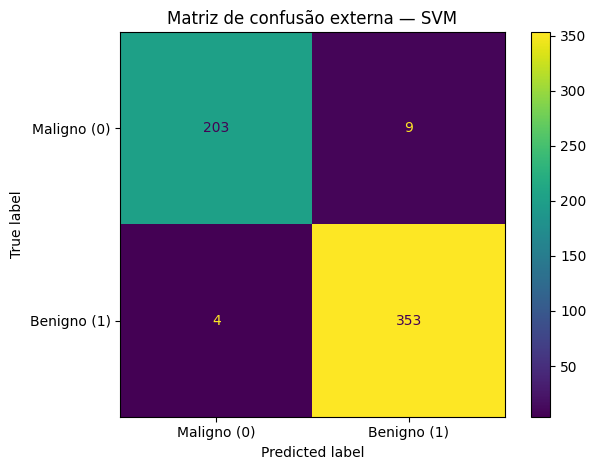

,Classe,Acertos,Total real,Taxa de acerto,Taxa de acerto (%)
0,Maligno (0),203,212,0.9575,95.7547
1,Benigno (1),353,357,0.9888,98.8796


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
rotulos = [0, 1]
nomes_classes = ["Maligno (0)", "Benigno (1)"]

matriz = confusion_matrix(y, y_pred_oof, labels=rotulos)

matriz_df = pd.DataFrame(
    matriz,
    index=[f"Real: {classe}" for classe in nomes_classes],
    columns=[f"Predito: {classe}" for classe in nomes_classes],
)
display(matriz_df)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nomes_classes,
).plot(values_format="d")
plt.title(
    f"Matriz de confusão externa — {nome_melhor_classificador}"
)
plt.tight_layout()
plt.show()

totais_por_classe = matriz.sum(axis=1)
acertos_por_classe = np.diag(matriz)
taxas_por_classe = acertos_por_classe / totais_por_classe

tabela_classes = pd.DataFrame({
    "Classe": nomes_classes,
    "Acertos": acertos_por_classe,
    "Total real": totais_por_classe,
    "Taxa de acerto": taxas_por_classe,
    "Taxa de acerto (%)": taxas_por_classe * 100,
})

display(tabela_classes.round(4))

## 11. Relatório por classe

In [12]:
relatorio = classification_report(
    y,
    y_pred_oof,
    labels=rotulos,
    target_names=nomes_classes,
    output_dict=True,
    zero_division=0,
)

display(pd.DataFrame(relatorio).T.round(4))

,precision,recall,f1-score,support
Maligno (0),0.9807,0.9575,0.9690,212.0000
Benigno (1),0.9751,0.9888,0.9819,357.0000
accuracy,0.9772,0.9772,0.9772,0.9772
macro avg,0.9779,0.9732,0.9754,569.0000
weighted avg,0.9772,0.9772,0.9771,569.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12. A.4 — Comparação entre acurácia e F1 com bootstrap estratificado

Em vez de aplicar teste t sobre apenas cinco folds dependentes, o notebook reamostra
as predições externas preservando a quantidade de casos de cada classe.

A estatística analisada é:

\[
d = \text{acurácia} - \text{F1 ponderado}
\]

Será apresentado um intervalo bootstrap de 95% para \(d\).

In [13]:
def bootstrap_estratificado_diferenca_metricas(
    y_true,
    y_pred,
    n_bootstrap=5000,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    indices_por_classe = {
        classe: np.flatnonzero(y_true == classe)
        for classe in np.unique(y_true)
    }

    diferencas = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        amostra = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in indices_por_classe.values()
        ])
        rng.shuffle(amostra)

        acc = accuracy_score(y_true[amostra], y_pred[amostra])
        f1 = f1_score(
            y_true[amostra],
            y_pred[amostra],
            average="weighted",
            zero_division=0,
        )
        diferencas[i] = acc - f1

    limite_inferior, limite_superior = np.quantile(
        diferencas,
        [0.025, 0.975],
    )

    return {
        "diferencas": diferencas,
        "media": diferencas.mean(),
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
    }

acuracia_oof = accuracy_score(y, y_pred_oof)
f1_oof = f1_score(
    y,
    y_pred_oof,
    average="weighted",
    zero_division=0,
)

bootstrap = bootstrap_estratificado_diferenca_metricas(
    y_true=y,
    y_pred=y_pred_oof,
    n_bootstrap=5000,
    random_state=RANDOM_STATE,
)

diferenca_observada = acuracia_oof - f1_oof
li = bootstrap["limite_inferior"]
ls = bootstrap["limite_superior"]

if li > 0 or ls < 0:
    conclusao_a4 = (
        "O intervalo de 95% não contém zero; há evidência de diferença "
        "entre as métricas nas predições externas."
    )
else:
    conclusao_a4 = (
        "O intervalo de 95% contém zero; não há evidência de diferença "
        "relevante entre as métricas nas predições externas."
    )

print(f"Acurácia OOF: {acuracia_oof:.4f}")
print(f"F1 ponderado OOF: {f1_oof:.4f}")
print(f"Diferença observada: {diferenca_observada:.6f}")
print(
    "IC bootstrap de 95% para acurácia - F1: "
    f"[{li:.6f}, {ls:.6f}]"
)
print(conclusao_a4)

Acurácia OOF: 0.9772
F1 ponderado OOF: 0.9771
Diferença observada: 0.000057
IC bootstrap de 95% para acurácia - F1: [-0.000017, 0.000199]
O intervalo de 95% contém zero; não há evidência de diferença relevante entre as métricas nas predições externas.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13. A.3 — Parâmetros finais para treinamento em toda a base

Após a avaliação externa, uma nova busca é feita em toda a base somente para definir
o modelo final. Esses parâmetros não são usados para recalcular as métricas externas.

In [14]:
configuracao_melhor = modelos_classificacao[nome_melhor_classificador]

busca_final = GridSearchCV(
    estimator=clone(configuracao_melhor["pipeline"]),
    param_grid=configuracao_melhor["param_grid"],
    scoring=scoring_classificacao,
    refit="f1_weighted",
    cv=cv_interna,
    n_jobs=N_JOBS,
    error_score="raise",
)

busca_final.fit(X, y)

parametros_finais = {
    chave.replace("model__", ""): valor
    for chave, valor in busca_final.best_params_.items()
}

print("Parâmetros finais:")
display(parametros_finais)

modelo_final_classificacao = busca_final.best_estimator_

Parâmetros finais:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'C': 1, 'kernel': 'linear'}

## 14. Respostas finais da Atividade A

In [15]:
taxa_maligno = 100 * taxas_por_classe[0]
taxa_benigno = 100 * taxas_por_classe[1]

resumo_vencedor = tabela_classificacao.iloc[0]

print("=" * 80)
print("ATIVIDADE A — RESULTADO METODOLOGICAMENTE CORRIGIDO")
print("=" * 80)
print(f"Indutor: {nome_melhor_classificador}")
print(
    "Acurácia média externa: "
    f"{resumo_vencedor['Acurácia média externa']:.4f}"
)
print(
    "F1 ponderado médio externo: "
    f"{resumo_vencedor['F1 médio externo']:.4f}"
)
print(
    "Precisão ponderada média externa: "
    f"{resumo_vencedor['Precisão média externa']:.4f}"
)
print(
    "Recall ponderado médio externo: "
    f"{resumo_vencedor['Recall médio externo']:.4f}"
)

print("\nA.1) Taxa de acerto de cada classe")
print(f"Maligno (0): {taxa_maligno:.2f}%")
print(f"Benigno (1): {taxa_benigno:.2f}%")

print("\nA.2) Matriz de confusão externa")
print(matriz)

print("\nA.3) Parâmetros finais")
print(parametros_finais)

print("\nA.4) Acurácia versus F1")
print(
    f"Acurácia OOF={acuracia_oof:.4f}; "
    f"F1 ponderado OOF={f1_oof:.4f}; "
    f"diferença={diferenca_observada:.6f}; "
    f"IC95%=[{li:.6f}, {ls:.6f}]."
)
print(conclusao_a4)

ATIVIDADE A — RESULTADO METODOLOGICAMENTE CORRIGIDO
Indutor: SVM
Acurácia média externa: 0.9772
F1 ponderado médio externo: 0.9770
Precisão ponderada média externa: 0.9777
Recall ponderado médio externo: 0.9772

A.1) Taxa de acerto de cada classe
Maligno (0): 95.75%
Benigno (1): 98.88%

A.2) Matriz de confusão externa
[[203   9]
 [  4 353]]

A.3) Parâmetros finais
{'C': 1, 'kernel': 'linear'}

A.4) Acurácia versus F1
Acurácia OOF=0.9772; F1 ponderado OOF=0.9771; diferença=0.000057; IC95%=[-0.000017, 0.000199].
O intervalo de 95% contém zero; não há evidência de diferença relevante entre as métricas nas predições externas.
